In [1]:
from google.colab import files
uploaded = files.upload()

Saving Data_set 2 - Copy.csv to Data_set 2 - Copy.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Data_set 2 - Copy.csv")

In [4]:
#Task 7: Common Information Sources

source_counts = df['Source'].value_counts()
print(source_counts)

print("\nPercentages:")
print(df['Source'].value_counts(normalize=True).mul(100).round(1))

Source
Financial Consultants       16
Newspapers and Magazines    14
Television                   6
Internet                     4
Name: count, dtype: int64

Percentages:
Source
Financial Consultants       40.0
Newspapers and Magazines    35.0
Television                  15.0
Internet                    10.0
Name: proportion, dtype: float64


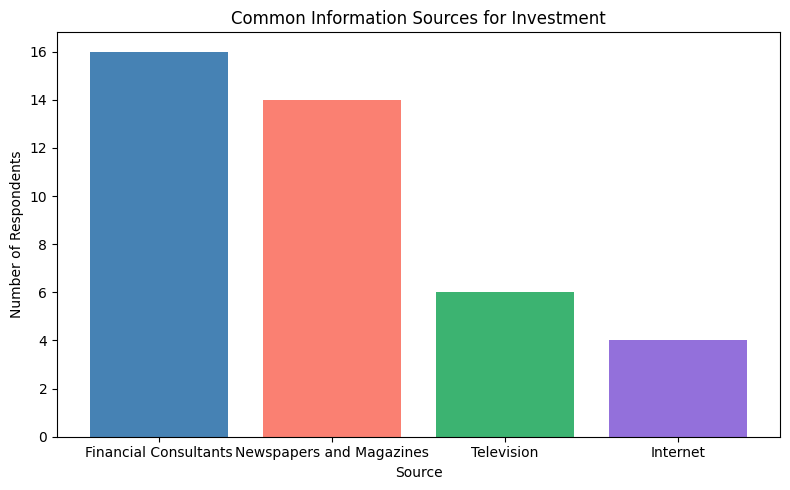

In [5]:
plt.figure(figsize=(8, 5))
plt.bar(source_counts.index, source_counts.values, color=['steelblue', 'salmon', 'mediumseagreen', 'mediumpurple'])
plt.title("Common Information Sources for Investment")
plt.xlabel("Source")
plt.ylabel("Number of Respondents")
plt.tight_layout()
plt.savefig("task7_sources.png")
plt.show()

In [6]:
#Task 8: Investment Duration

duration_counts = df['Duration'].value_counts()
print(duration_counts)

print("\nPercentages:")
print(df['Duration'].value_counts(normalize=True).mul(100).round(1))

Duration
3-5 years            19
1-3 years            18
Less than 1 year      2
More than 5 years     1
Name: count, dtype: int64

Percentages:
Duration
3-5 years            47.5
1-3 years            45.0
Less than 1 year      5.0
More than 5 years     2.5
Name: proportion, dtype: float64


In [7]:
duration_map = {
    'Less than 1 year': 0.5,
    '1-3 years': 2,
    '3-5 years': 4,
    'More than 5 years': 6
}

df['Duration_numeric'] = df['Duration'].map(duration_map)
avg_duration = df['Duration_numeric'].mean().round(2)
print(f"Average Investment Duration: {avg_duration} years")

Average Investment Duration: 2.98 years


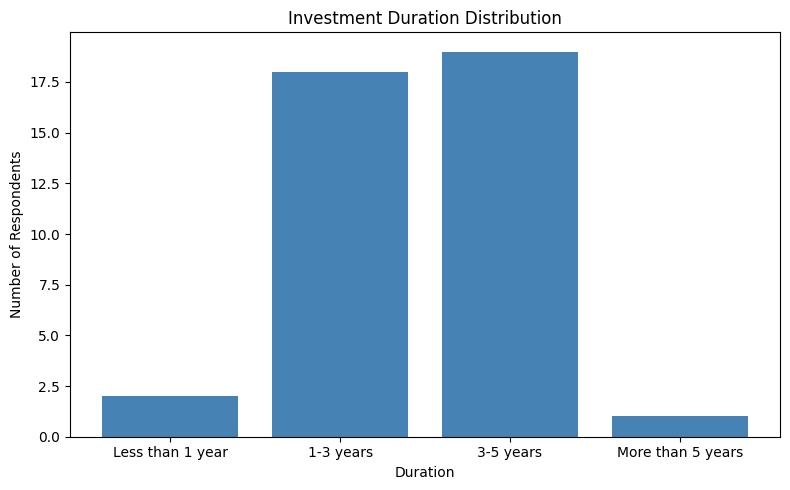

In [8]:
plt.figure(figsize=(8, 5))
order = ['Less than 1 year', '1-3 years', '3-5 years', 'More than 5 years']
counts = df['Duration'].value_counts().reindex(order)
plt.bar(counts.index, counts.values, color='steelblue')
plt.title("Investment Duration Distribution")
plt.xlabel("Duration")
plt.ylabel("Number of Respondents")
plt.tight_layout()
plt.savefig("task8_duration.png")
plt.show()

In [9]:
#Task 9: Expectations from Investments

expect_counts = df['Expect'].value_counts()
print(expect_counts)

print("\nPercentages:")
print(df['Expect'].value_counts(normalize=True).mul(100).round(1))

Expect
20%-30%    32
30%-40%     5
10%-20%     3
Name: count, dtype: int64

Percentages:
Expect
20%-30%    80.0
30%-40%    12.5
10%-20%     7.5
Name: proportion, dtype: float64


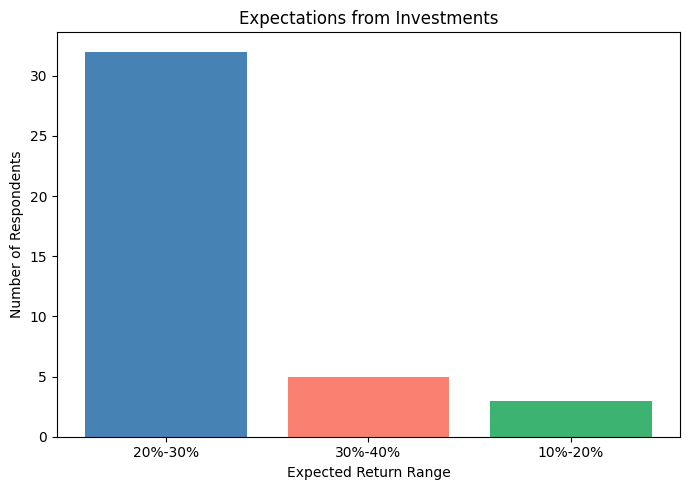

In [10]:
plt.figure(figsize=(7, 5))
plt.bar(expect_counts.index, expect_counts.values, color=['steelblue', 'salmon', 'mediumseagreen'])
plt.title("Expectations from Investments")
plt.xlabel("Expected Return Range")
plt.ylabel("Number of Respondents")
plt.tight_layout()
plt.savefig("task9_expectations.png")
plt.show()

In [12]:
#Task 10: Correlation Analysis

numerical_df = df.select_dtypes(include='number')

corr_matrix = numerical_df.corr().round(2)
print(corr_matrix)

                   age  Mutual_Funds  Equity_Market  Debentures  \
age               1.00         -0.12           0.25        0.33   
Mutual_Funds     -0.12          1.00           0.33       -0.35   
Equity_Market     0.25          0.33           1.00       -0.02   
Debentures        0.33         -0.35          -0.02        1.00   
Government_Bonds -0.09         -0.11          -0.24        0.43   
Fixed_Deposits   -0.03         -0.03          -0.24       -0.47   
PPF              -0.26         -0.19          -0.43       -0.51   
Gold             -0.06         -0.40          -0.05       -0.14   
Duration_numeric  0.05          0.18           0.47        0.03   

                  Government_Bonds  Fixed_Deposits   PPF  Gold  \
age                          -0.09           -0.03 -0.26 -0.06   
Mutual_Funds                 -0.11           -0.03 -0.19 -0.40   
Equity_Market                -0.24           -0.24 -0.43 -0.05   
Debentures                    0.43           -0.47 -0.51 -0.14   

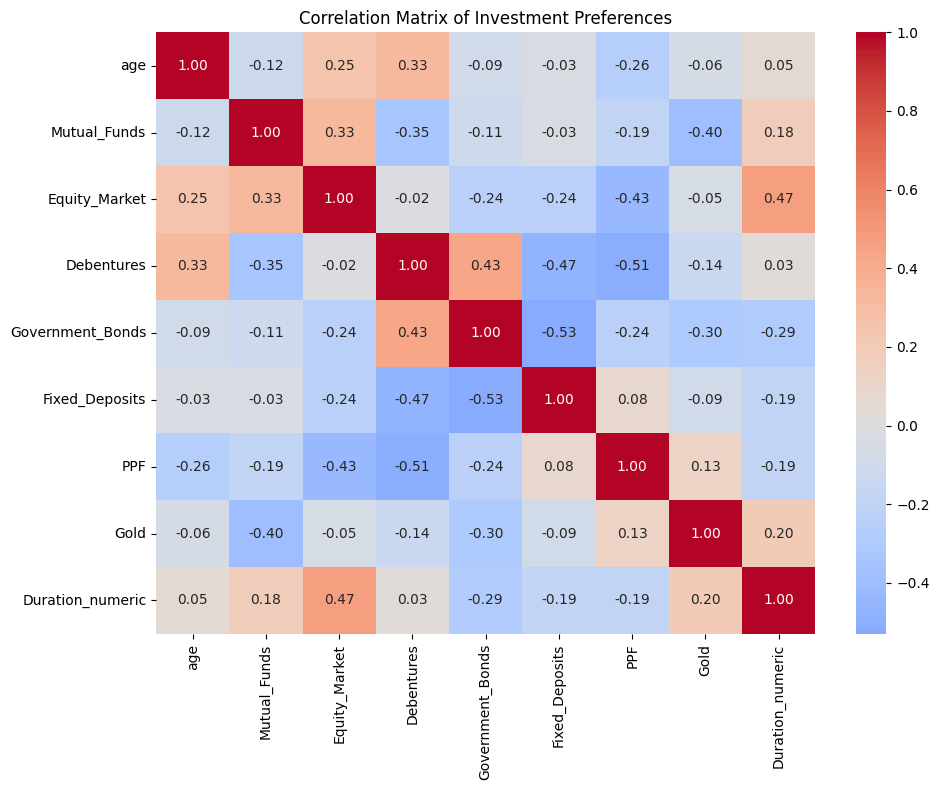

In [13]:
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            center=0,
            fmt='.2f')
plt.title("Correlation Matrix of Investment Preferences")
plt.tight_layout()
plt.savefig("task10_correlation.png")
plt.show()